#### Instructions:  
1. Libraries allowed: **Python basic libraries, numpy.** except the functions explicitly mentioned.
2. Show all outputs.
3. Submit jupyter notebook and a pdf export of the notebook. 


## Task
This assignment will prepare you for the image stitching task, which you will be doing in the next assignment. This task involves building a pipeline for finding correspondences between two images that includes feature detection, description, and matching.

## Keypoint detection

Q1. In this part, you will implement a harris corner detector from scratch. Use the opencv function, `cv2.filter2D(src, ddepth, kernel[, dst[, anchor[, delta[, borderType]]]]	) ->	dst` for linear filtering and `cv2.copyMakeBorder()` for padding. `ddepth` argument in the `filter2D` function to 64-bit data type `cv.CV_64F`, which is default for numpy. Use "reflection" for padding. All other codes need to be implemented from scratch using basic python and numbpy libraries. Use matplotlib for visualization.

a) Take an image of a scene that contains corner like features, e.g., buildings, furnitures. Load the image using PIL and convert it to grayscale. Normalize the image between 0 and 1.

In [3]:
from PIL import Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

0.0 1.0 (2455, 2265)


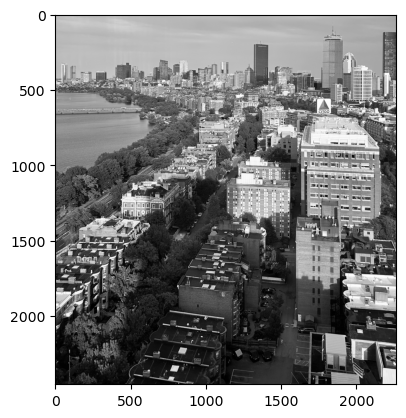

In [4]:
img = Image.open("jengabuilding.jpg")
grayscale_img = img.convert('L')
img_normalized = np.array(grayscale_img, dtype=np.float64) / 255.0

print(img_normalized.min(), img_normalized.max(), img_normalized.shape)
plt.imshow(img_normalized, cmap='gray')

b) Write the horizontal and vertical sobel filter.

In [5]:
horizontal_sobel = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
vertical_sobel = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

c) use the sobel filters to calculate $I_x$ and $I_y$ using  `cv2.filter2d`. Apply padding to keep the output size unchanged.

Ix shape: (2455, 2265) Iy shape: (2455, 2265)


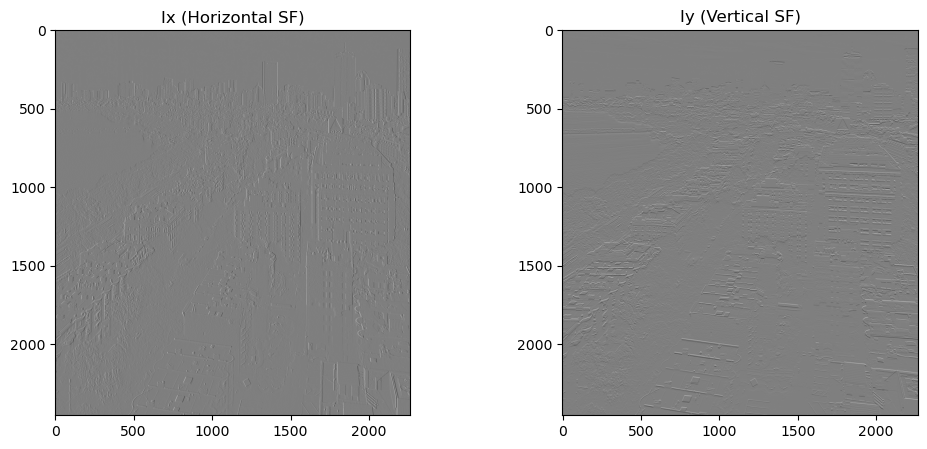

In [6]:
pad = 1
gray_pad = cv2.copyMakeBorder(img_normalized, pad, pad, pad, pad, borderType=cv2.BORDER_REFLECT_101)

Ix_pad = cv2.filter2D(gray_pad, ddepth=cv2.CV_64F, kernel=horizontal_sobel)
Iy_pad = cv2.filter2D(gray_pad, ddepth=cv2.CV_64F, kernel=vertical_sobel)

Ix = Ix_pad[pad:-pad, pad:-pad]
Iy = Iy_pad[pad:-pad, pad:-pad]

print("Ix shape:", Ix.shape, "Iy shape:", Iy.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Ix (Horizontal SF)")
plt.imshow(Ix, cmap="gray")

plt.subplot(1, 2, 2)
plt.title("Iy (Vertical SF)")
plt.imshow(Iy, cmap="gray")
plt.show()


d) Calculate $\sum w(x,y) I_x^2$,  $\sum w(x,y) I_y^2$, and  $\sum w(x,y) I_x I_y$. Use a gaussian filter of size $5\times5$ with $\sigma=0.5$. Apply padding to keep the output size unchanged.

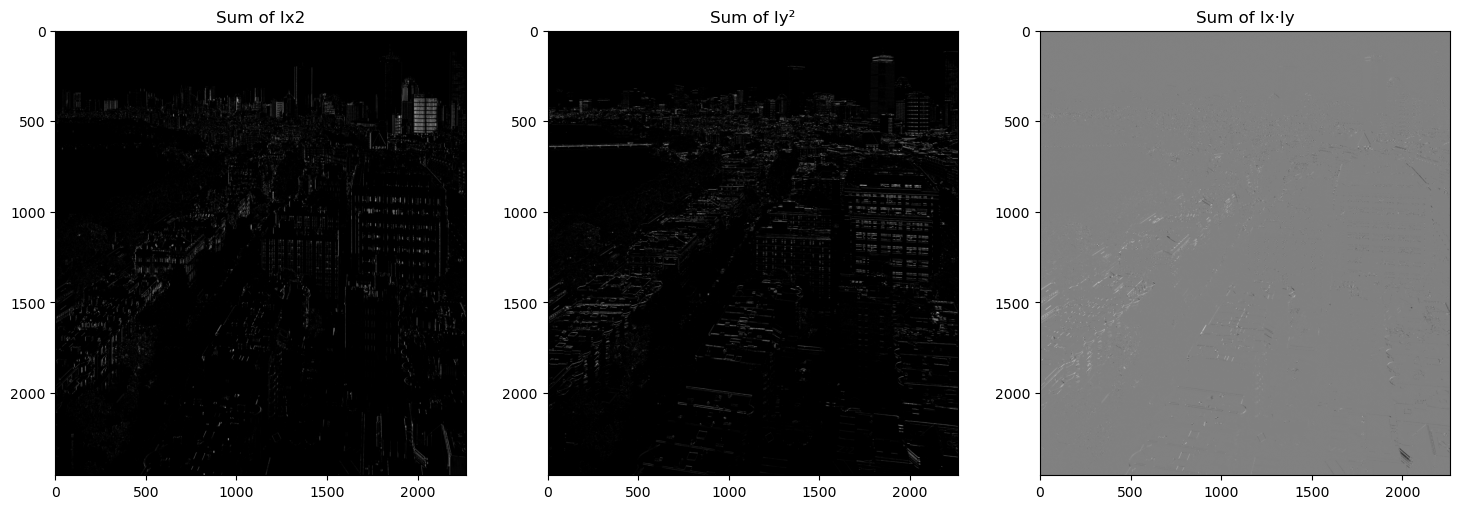

In [7]:
Ix2 = Ix * Ix
Iy2 = Iy * Iy
Ixy = Ix * Iy

sigma = 0.5
size = 5
center = size // 2  # = 2

gaussian_kernel = np.zeros((size, size))
for i in range(size):
    for j in range(size):
        x = i - center
        y = j - center
        gaussian_kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))

gaussian_kernel = gaussian_kernel / gaussian_kernel.sum()


Ix2 = Ix * Ix
Iy2 = Iy * Iy
IxIy = Ix * Iy

pad = 2
Ix2_pad = cv2.copyMakeBorder(Ix2, pad, pad, pad, pad, borderType=cv2.BORDER_REFLECT_101)
Iy2_pad = cv2.copyMakeBorder(Iy2, pad, pad, pad, pad, borderType=cv2.BORDER_REFLECT_101)
IxIy_pad = cv2.copyMakeBorder(IxIy, pad, pad, pad, pad, borderType=cv2.BORDER_REFLECT_101)

Sx2 = cv2.filter2D(Ix2_pad, ddepth=cv2.CV_64F, kernel=gaussian_kernel)
Sy2 = cv2.filter2D(Iy2_pad, ddepth=cv2.CV_64F, kernel=gaussian_kernel)
Sxy = cv2.filter2D(IxIy_pad, ddepth=cv2.CV_64F, kernel=gaussian_kernel)

Sx2 = Sx2[pad:-pad, pad:-pad]
Sy2 = Sy2[pad:-pad, pad:-pad]
Sxy = Sxy[pad:-pad, pad:-pad]

plt.figure(figsize=(18, 7))

plt.subplot(1, 3, 1)
plt.title("Sum of Ix2")
plt.imshow(Sx2, cmap="gray")

plt.subplot(1, 3, 2)
plt.title("Sum of Iy²")
plt.imshow(Sy2, cmap="gray")

plt.subplot(1, 3, 3)
plt.title("Sum of Ix·Iy")
plt.imshow(Sxy, cmap="gray")

plt.show()

e) For each pixel, calculate the structure tensor, $M(x,y)$, as described in the lecture slides and $R(x,y)$ as $R = det(M) - 0.06 (trace(M))^2$. Put $R$ in a matrix.

[[-2.66402887e-09 -2.66101928e-09 -1.47201525e-09 ...  9.27037098e-10
   1.81063625e-09  5.03591400e-10]
 [-6.12974986e-08 -6.12830648e-08 -5.60401214e-08 ...  2.67113599e-09
   7.97917679e-10  8.54158242e-10]
 [-2.60247845e-07 -2.60218005e-07 -2.49416788e-07 ... -4.76752968e-10
  -6.30902719e-10 -6.45928141e-11]
 ...
 [-1.07494502e-06 -1.58225333e-05 -1.06589330e-06 ... -8.20593856e-03
  -3.07303033e-03 -1.47786473e-04]
 [-1.05798178e-06 -1.41359691e-05 -4.29124685e-07 ... -8.50973177e-03
  -2.95849874e-03 -1.39651794e-04]
 [-8.98052965e-07 -1.26169188e-05 -1.13675781e-06 ... -8.65515897e-03
  -2.90161818e-03 -1.35581350e-04]]


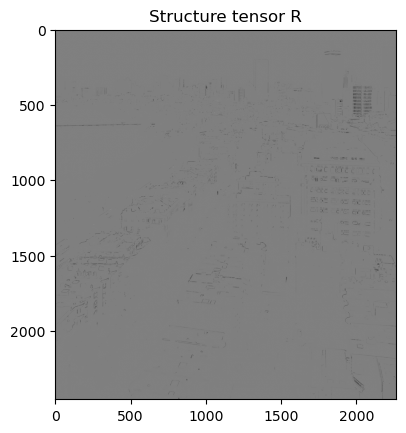

In [8]:
det_M = Sx2 * Sy2 - Sxy**2
trace_M = Sx2 + Sy2
R = det_M - 0.06 * trace_M**2
print(R)
plt.imshow(R, cmap="gray")
plt.title("Structure tensor R")
plt.show()

f) Apply thresholding to find the high responses by setting the values above the threshold to 1 and below to 0. 

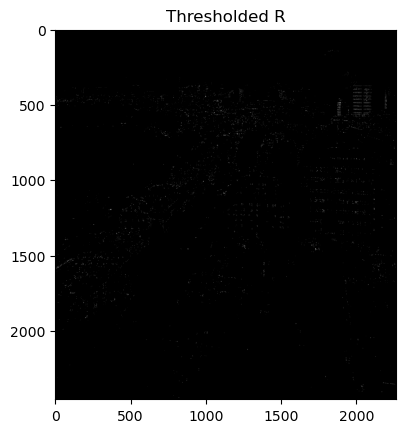

In [17]:
threshold = 0.05 * R.max()
R_thresholded = np.where(R > threshold, 1, 0)

plt.imshow(R_thresholded, cmap="gray")
plt.title("Thresholded R")
plt.show()

g) Do non-maximum suppression. Use a $7\times 7$ window to suppress non-maximum keypoints. Put the keypoints in a list of tuples as $keypoints = [(x1, y1), ..., (xn,yn)]$

In [18]:
pad = 3
R_padded = cv2.copyMakeBorder(R_thresholded * R, pad, pad, pad, pad, borderType=cv2.BORDER_REFLECT_101)

keypoints = []
for i in range(pad, R_padded.shape[0] - pad):
    for j in range(pad, R_padded.shape[1] - pad):
        window = R_padded[i - pad:i + pad + 1, j - pad:j + pad + 1]
        if R_padded[i, j] == window.max() and R_padded[i, j] > 0:
            keypoints.append((j - pad, i - pad))  # (x, y) format

print(f"Number of keypoints: {len(keypoints)}")

Number of keypoints: 4666


g) Visualize the keypoints Use online resources to convert keypoints. Then use `cv2.drawKeypoints()` to draw the keypoints.

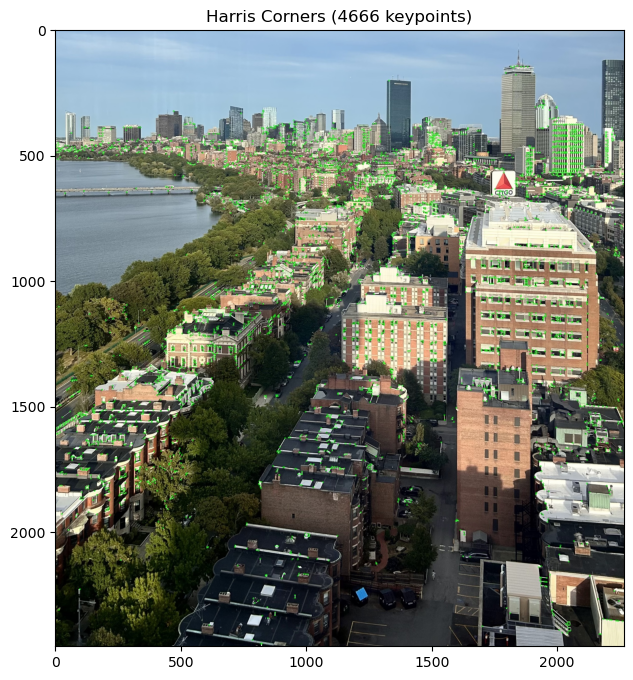

In [19]:
cv_keypoints = [cv2.KeyPoint(float(x), float(y), 1) for x, y in keypoints]


img_with_keypoints = cv2.drawKeypoints(np.array(img), cv_keypoints, None, color=(0, 255, 0))

plt.figure(figsize=(10, 8))
plt.imshow(img_with_keypoints)
plt.title(f"Harris Corners ({len(keypoints)} keypoints)")
plt.show()

h) Combine steps (b) to (g) in a function that takes img and threshold as arguments and return the keypoints.

In [23]:
def harris_corner_detector(image, threhold=0.5):
    horizontal_sobel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    vertical_sobel = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

    pad = 1
    gray_pad = cv2.copyMakeBorder(image, pad, pad, pad, pad, borderType=cv2.BORDER_REFLECT_101)
    Ix_pad = cv2.filter2D(gray_pad, ddepth=cv2.CV_64F, kernel=horizontal_sobel)
    Iy_pad = cv2.filter2D(gray_pad, ddepth=cv2.CV_64F, kernel=vertical_sobel)
    Ix = Ix_pad[pad:-pad, pad:-pad]
    Iy = Iy_pad[pad:-pad, pad:-pad]

    sigma = 0.5
    size = 5
    center = size // 2
    gaussian_kernel = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            x = i - center
            y = j - center
            gaussian_kernel[i, j] = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    gaussian_kernel = gaussian_kernel / gaussian_kernel.sum()

    Ix2 = Ix * Ix
    Iy2 = Iy * Iy
    IxIy = Ix * Iy

    pad = 2
    Ix2_pad = cv2.copyMakeBorder(Ix2, pad, pad, pad, pad, borderType=cv2.BORDER_REFLECT_101)
    Iy2_pad = cv2.copyMakeBorder(Iy2, pad, pad, pad, pad, borderType=cv2.BORDER_REFLECT_101)
    IxIy_pad = cv2.copyMakeBorder(IxIy, pad, pad, pad, pad, borderType=cv2.BORDER_REFLECT_101)

    Sx2 = cv2.filter2D(Ix2_pad, ddepth=cv2.CV_64F, kernel=gaussian_kernel)[pad:-pad, pad:-pad]
    Sy2 = cv2.filter2D(Iy2_pad, ddepth=cv2.CV_64F, kernel=gaussian_kernel)[pad:-pad, pad:-pad]
    Sxy = cv2.filter2D(IxIy_pad, ddepth=cv2.CV_64F, kernel=gaussian_kernel)[pad:-pad, pad:-pad]

    det_M = Sx2 * Sy2 - Sxy**2
    trace_M = Sx2 + Sy2
    R = det_M - 0.06 * trace_M**2

    R_thresholded = np.where(R > threshold * R.max(), 1, 0)

    pad = 3
    R_padded = cv2.copyMakeBorder(R_thresholded * R, pad, pad, pad, pad, borderType=cv2.BORDER_REFLECT_101)
    keypoints = []
    for i in range(pad, R_padded.shape[0] - pad):
        for j in range(pad, R_padded.shape[1] - pad):
            window = R_padded[i - pad:i + pad + 1, j - pad:j + pad + 1]
            if R_padded[i, j] == window.max() and R_padded[i, j] > 0:
                keypoints.append((j - pad, i - pad))

    return keypoints


keypoints = harris_corner_detector(img_normalized, 0.01)
print(f"Number of keypoints: {len(keypoints)}")

Number of keypoints: 7


## Feature descriptor
Q2. a) Here, you will build a simple feature descritptor, which is the intensities in the $5\times5$ neighboorhood.. For each keypoint, find the feature descriptors.


In [24]:
def get_descriptors(img, keypoints):
    pad = 2  # 5x5 window → pad of 2
    img_padded = cv2.copyMakeBorder(img, pad, pad, pad, pad, borderType=cv2.BORDER_REFLECT_101)
    
    descriptors = []
    for (x, y) in keypoints:
        # Shift by pad since image is padded
        patch = img_padded[y:y + 5, x:x + 5]
        descriptors.append(patch.flatten())  # 25-element vector
    
    return np.array(descriptors)

descriptors = get_descriptors(img_normalized, keypoints)
print(f"Descriptors shape: {descriptors.shape}")  # (num_keypoints, 25)

Descriptors shape: (7, 25)


b) Create a second image by running the following code that will translate the original image.

In [12]:
t_x = 30
t_y = 50
H = np.array([[1.0,0, t_x],
              [0.0,1.0, t_y]])

img2 = cv.warpAffine(img, H, (img.shape[1], img.shape[0]))

NameError: name 'cv' is not defined

c) Detect keypoints and find the feature descriptors for `img2`. 

## Matching
Q3. a) We want to find correspondence from the keypoints in the first image to keypoints in the second image. For that you wil compare two features and calculate a scalar distance
between them. The best match is the feature with the smallest distance. You will implement the followings:
1. Sum of squared differences (SSD): This is the the squared Euclidean distance between the two feature vectors.
2. The ratio test: Find the closest and second closest features by SSD distance. The ratio test distance is their ratio (i.e., SSD distance of the closest feature match divided by SSD distance of the second closest feature match).

For each keypoint in the first image, do the ratio test. If the ratio is below a threshold, then there is a match. Store the matches as a list of tuples of source keypoint index and target keypoint index. 

b) Use online resources to convert keypoints and matches to opencv format. Then use `cv2.drawKeypoints()` to draw the keypoints in both images and `cv2.drawMatches()` to visualize the matched keypoints. Note that coordinate system for opencv is differnt from numpy-- x-axis (column) is in horizontal direction and y-axis (row) is in vertical direction. You may need to switch the axis to properly visualize with opencv functions.

Q4. Now repeat all previous steps to find correspondences when the target image is obtained by rotation and scaled. The code to rotate an image is provided below.

In [ ]:
# Rotating the image after Warp
center = (img.shape[1]//2, img.shape[0]//2)
angle = 30
scale = 0.7

rot_mat = cv.getRotationMatrix2D( center, angle, scale )
img3 = cv.warpAffine(warp_dst, rot_mat, (img.shape[1], img.shape[0]))

In [ ]:
# code

b) Compare the peformances of the intensity based descriptor for rotation and translation and explain.

In [ ]:
# code

## SIFT keypoint detector and descriptor
Q5. a) Apply SIFT to extract keypoints and descritors from both images. Reference code is provided below

In [ ]:
"""
sift = cv.SIFT_create()
kp, des = sift.detectAndCompute(gray,None)
"""

b) Match the keypoints and visualize both keytpoints and matches.

c) Compare the peformance of SIFT with the intensity descriptor in the previous question.